Step size h = 0.01
Eigenvalues = [1.+0.01j 1.-0.01j]
|eigenvalues| = [1.00005 1.00005]
Solution may not be Entirely Stable ;)
--------------------------------------------------


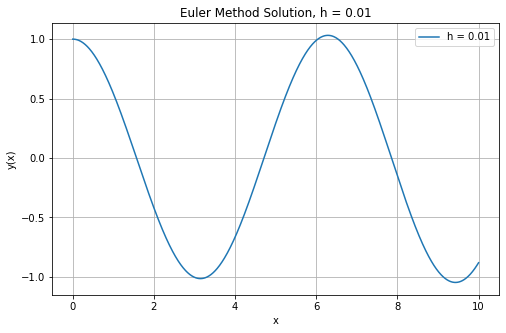

Step size h = 0.05
Eigenvalues = [1.+0.05j 1.-0.05j]
|eigenvalues| = [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)
--------------------------------------------------


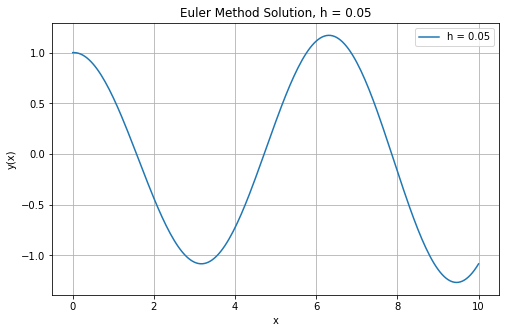

Step size h = 0.1
Eigenvalues = [1.+0.1j 1.-0.1j]
|eigenvalues| = [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)
--------------------------------------------------


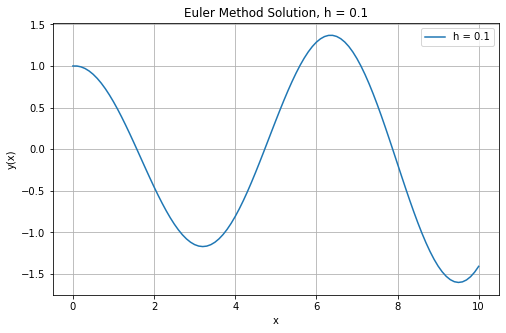

Step size h = 0.2
Eigenvalues = [1.+0.2j 1.-0.2j]
|eigenvalues| = [1.0198039 1.0198039]
Solution may not be Entirely Stable ;)
--------------------------------------------------


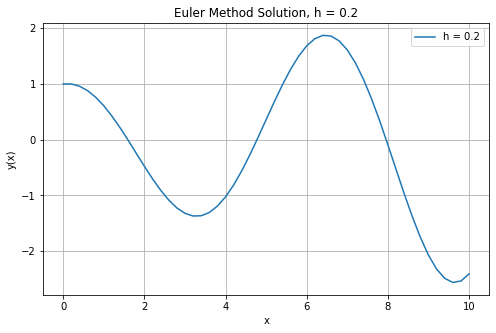

Step size h = 0.5
Eigenvalues = [1.+0.5j 1.-0.5j]
|eigenvalues| = [1.11803399 1.11803399]
Solution may not be Entirely Stable ;)
--------------------------------------------------


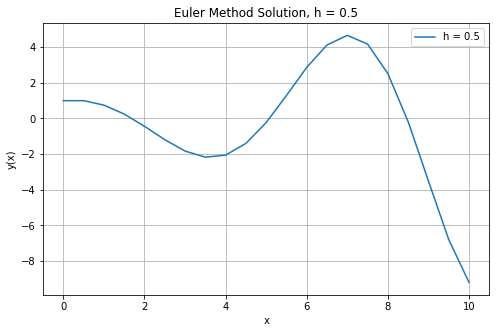

Step size h = 1.0
Eigenvalues = [1.+1.j 1.-1.j]
|eigenvalues| = [1.41421356 1.41421356]
Solution may not be Entirely Stable ;)
--------------------------------------------------


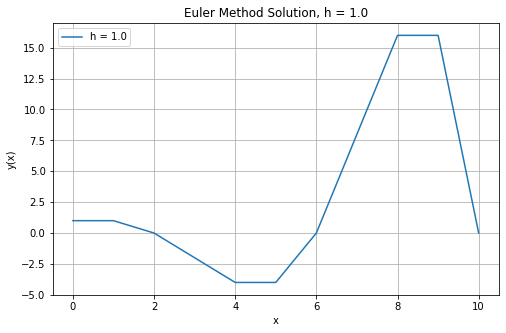

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0
h_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
x_start = 0.0
x_end = 10.0

# Initial conditions
y0 = 1.0
v0 = 0.0

# Continuous-time system matrix for y'' + ky = 0
A = np.array([
    [0, 1],
    [-k, 0]
], dtype=float)

for h in h_values:
    # Euler coefficient/update matrix
    M = np.eye(2) + h * A

    # Compute eigenvalues
    eigvals = np.linalg.eigvals(M)
    magnitudes = np.abs(eigvals)

    # Stability check
    if np.all(magnitudes < 1):
        stability_msg = "Solution is Stable"
    else:
        stability_msg = "Solution may not be Entirely Stable ;)"

    # Time grid
    x_values = np.arange(x_start, x_end + h, h)

    # Storage for solution
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions
    y_values[0] = y0
    v_values[0] = v0

    # Euler simulation
    for n in range(len(x_values) - 1):
        state_n = np.array([y_values[n], v_values[n]])
        state_next = M @ state_n

        y_values[n + 1] = state_next[0]
        v_values[n + 1] = state_next[1]

    # Output
    print(f"Step size h = {h}")
    print(f"Eigenvalues = {eigvals}")
    print(f"|eigenvalues| = {magnitudes}")
    print(stability_msg)
    print("-" * 50)

    # Plot solution curve
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, label=f"h = {h}")
    plt.title(f"Euler Method Solution, h = {h}")
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.grid(True)
    plt.legend()
    plt.show()